## Detectar agrupaciones en el dataset Diabetes

### Primer paso cargar librerias

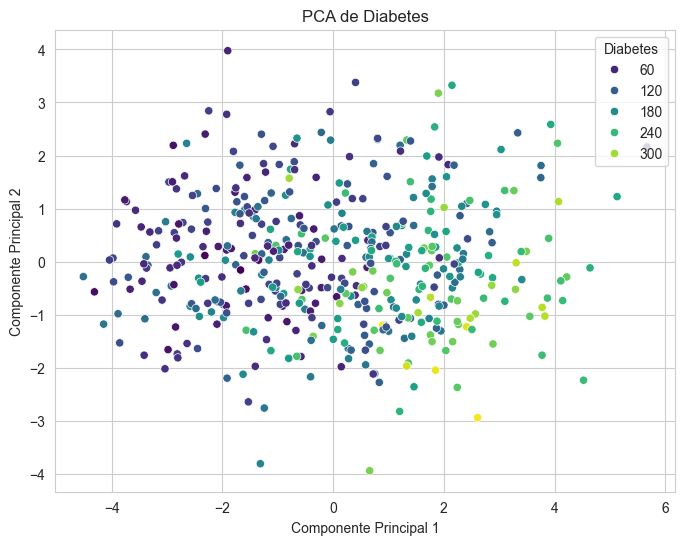

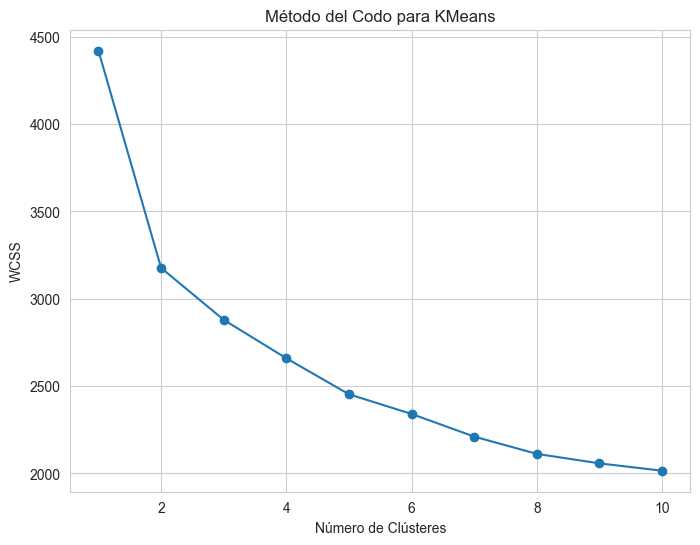

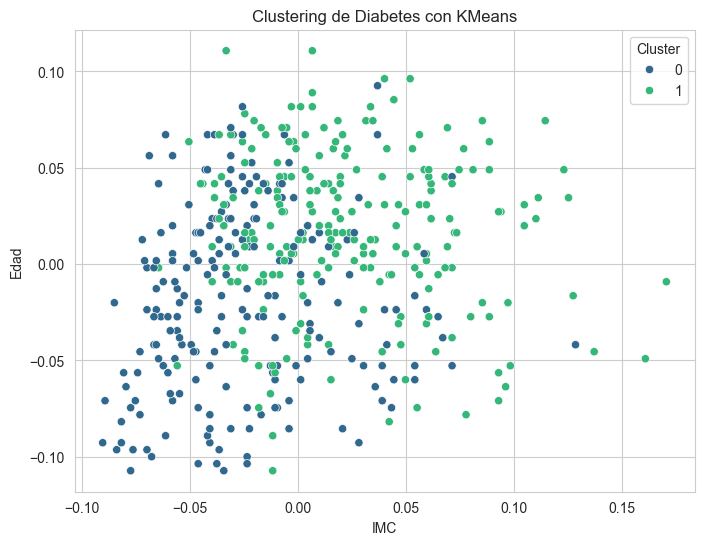

Silhouette Score: 0.2369690811266377
Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.


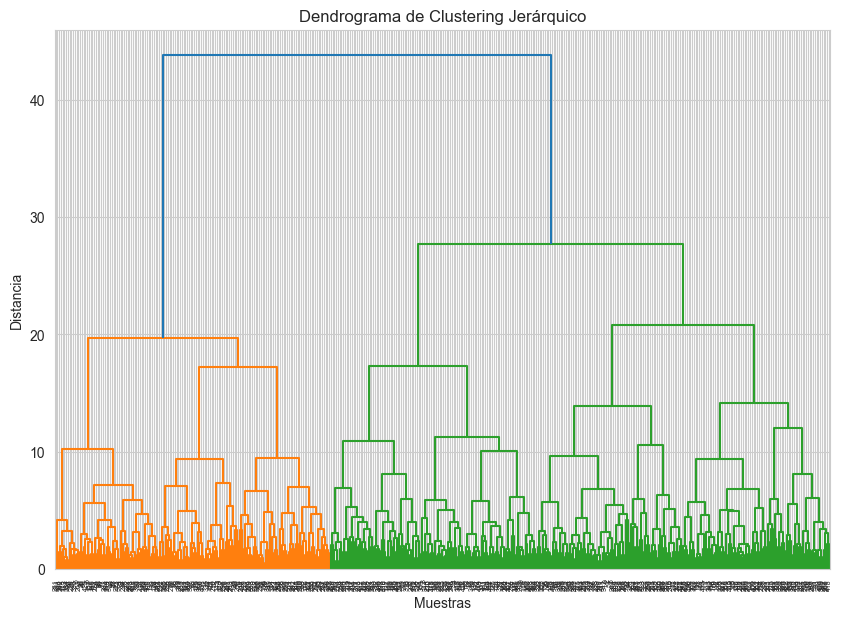

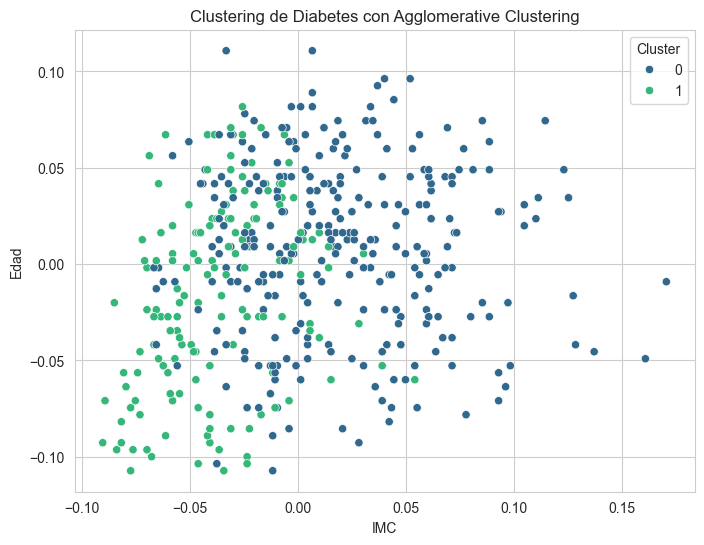

Silhouette Score (Agglomerative Clustering): 0.17995042366462588
Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.


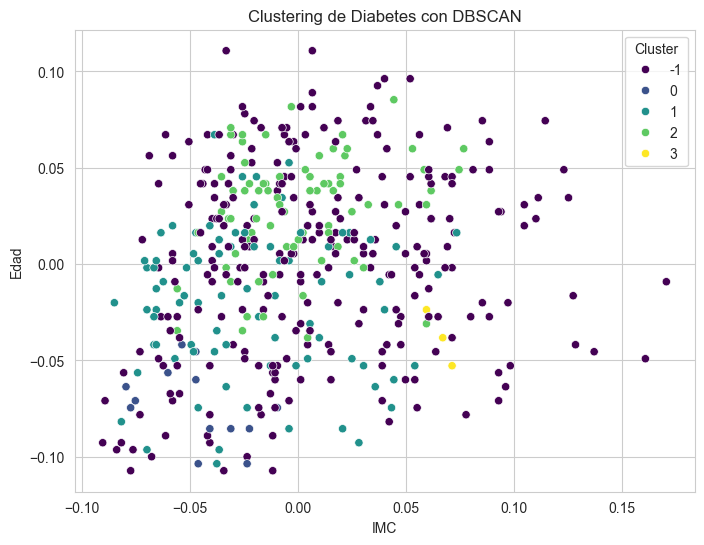

Silhouette Score (DBSCAN): -0.07328336260233378
Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.


In [ ]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.datasets import load_diabetes

sns.set_style('whitegrid')

# Cargar datos
diabetes = load_diabetes()
X_diabetes = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
y_diabetes = diabetes.target

# Escalado de características
X_diabetes_scaled = StandardScaler().fit_transform(X_diabetes)

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=2) # Reducir a 2 componentes principales
X_diabetes_pca = pca.fit_transform(X_diabetes_scaled) # Transformar los datos escalados
X_diabetes_pca_df = pd.DataFrame(data=X_diabetes_pca, columns=['PC1', 'PC2']) # Crear DataFrame con componentes principales

# Visualizar los datos en 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_diabetes_pca_df, x='PC1', y='PC2', hue=y_diabetes, palette='viridis')
plt.title('PCA de Diabetes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Diabetes', loc='upper right')
plt.grid(True)
plt.show()

# Grafica del codo para KMeans
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42) # Inicializar KMeans
    kmeans.fit(X_diabetes_scaled) # Ajustar el modelo
    wcss.append(kmeans.inertia_) # Almacenar la inercia
# Visualizar el método del codo
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo para KMeans')
plt.xlabel('Número de Clústeres')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Aplicar KMeans
kmeans_diabetes = KMeans(n_clusters=2, random_state=42) # Elegir 3 clústeres basado en el codo
kmeans_diabetes.fit(X_diabetes_scaled) # Ajustar el modelo
X_diabetes['Cluster'] = kmeans_diabetes.labels_ # Asignar etiquetas de clúster

# Visualizar los clústeres
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_diabetes, x='bmi', y='age', hue='Cluster', palette='viridis')
plt.title('Clustering de Diabetes con KMeans')
plt.xlabel('IMC')
plt.ylabel('Edad')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Evaluar el clustering con silhouette score, una métrica de calidad de clústeres
silhouette_avg = silhouette_score(X_diabetes_scaled, kmeans_diabetes.labels_)
print(f'Silhouette Score: {silhouette_avg}')
print("Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.") 

# Realizar clustering jerárquico
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_diabetes_scaled, method='ward'))
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

agg_diabetes = AgglomerativeClustering(n_clusters=2, linkage='ward') # Elegir 2 clústeres basado en el dendrograma
X_diabetes['Cluster_Agg'] = agg_diabetes.fit_predict(X_diabetes_scaled) # Asignar etiquetas de clúster

# Visualizar los clústeres jerárquicos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_diabetes, x='bmi', y='age', hue='Cluster_Agg', palette='viridis')
plt.title('Clustering de Diabetes con Agglomerative Clustering')
plt.xlabel('IMC')
plt.ylabel('Edad')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Evaluar el clustering jerárquico con silhouette score
silhouette_avg_agg = silhouette_score(X_diabetes_scaled, agg_diabetes.labels_)
print(f'Silhouette Score (Agglomerative Clustering): {silhouette_avg_agg}')
print("Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.")

# Aplicar DBSCAN
dbscan_diabetes = DBSCAN(eps=1.5, min_samples=5) # Ajustar DBSCAN con parámetros adecuados
dbscan_diabetes.fit(X_diabetes_scaled) # Ajustar el modelo
X_diabetes['Cluster_DBSCAN'] = dbscan_diabetes.labels_ # Asignar etiquetas de clúster

# Visualizar los clústeres de DBSCAN
plt.figure(figsize=(8, 6))
sns.scatterplot(data=X_diabetes, x='bmi', y='age', hue='Cluster_DBSCAN', palette='viridis')
plt.title('Clustering de Diabetes con DBSCAN')
plt.xlabel('IMC')
plt.ylabel('Edad')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Evaluar el clustering de DBSCAN con silhouette score
silhouette_avg_dbscan = silhouette_score(X_diabetes_scaled, dbscan_diabetes.labels_)
print(f'Silhouette Score (DBSCAN): {silhouette_avg_dbscan}')
print("Un valor cercano al 0 indica clústeres superpuestos, mientras que un valor cercano a 1 indica clústeres bien definidos.")    
